# 05 — Revenue Anomaly Detection (IsolationForest)

## Purpose
This notebook detects unusual daily revenue behaviour using an unsupervised machine learning approach.

The goal is to:
- aggregate daily revenue at the country-day level from the validated PostgreSQL warehouse
- engineer temporal and lag-based features
- detect unusual country-level revenue patterns using IsolationForest
- assign anomaly direction labels for downstream BI use
- write scored anomaly outputs back into PostgreSQL for dashboard use

This notebook uses the validated warehouse tables and avoids flat-file-only analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from sqlalchemy import text

sys.path.insert(0, '..')
from src.utils.db_loader import get_engine
from src.ml.isolation_forest import detect_anomalies

engine = get_engine()

## Step 1 — Pull daily revenue base from PostgreSQL

We build the anomaly input directly from the warehouse by aggregating revenue and order volume by day and country.

This creates the country-day analytical grain used by the anomaly model.

In [2]:
daily_sql = """
SELECT
    order_date,
    country_name,
    daily_revenue,
    daily_orders
FROM vw_daily_revenue
ORDER BY order_date, country_name
"""

daily = pd.read_sql(daily_sql, engine, parse_dates=["order_date"])

print("Daily anomaly base shape:", daily.shape)
display(daily.head())
display(daily.describe(include="all"))

Daily anomaly base shape: (2893, 4)


,order_date,country_name,daily_revenue,daily_orders
0,2009-12-01,Australia,196.10,1
1,2009-12-01,Belgium,130.00,1
2,2009-12-01,EIRE,1800.43,3
3,2009-12-01,France,1030.24,2
4,2009-12-01,Germany,929.92,1


,order_date,country_name,daily_revenue,daily_orders
count,2893,2893,2893.000000,2893.000000
unique,NaN,43,NaN,NaN
top,NaN,United Kingdom,NaN,NaN
freq,NaN,604,NaN,NaN
mean,2011-01-03 18:09:05.039751168,NaN,7077.993087,13.853439
min,2009-12-01 00:00:00,NaN,2.950000,1.000000
25%,2010-07-14 00:00:00,NaN,398.520000,1.000000
50%,2011-01-07 00:00:00,NaN,944.500000,1.000000
75%,2011-07-14 00:00:00,NaN,4345.100000,3.000000
max,2011-12-09 00:00:00,NaN,196114.480000,151.000000


## Daily revenue base summary

The daily anomaly base contains **2,893 country-day rows** across **43 countries**.

### Observations
- the data spans from **2009-12-01** to **2011-12-09**
- the median daily revenue is much lower than the maximum, indicating a strongly right-skewed distribution
- the United Kingdom appears most frequently in the base table, which is expected given its dominance in the source retail data

Because revenue volume varies substantially across countries, anomaly detection should be performed within country rather than across the full pooled dataset.

## Step 2 — Run country-level anomaly detection

We apply IsolationForest separately within each country after creating temporal and lag-based features.

### Features used
- daily revenue
- daily orders
- day of week
- month
- previous day's revenue
- 7-period rolling revenue average

### Modeling note
Countries with too little history are not force-scored.  
Instead, they are marked as skipped for low history and excluded from the final PostgreSQL anomaly table.

### Contamination note
The model uses a fixed contamination value of **0.05**, which means it is allowed to flag roughly 5% of scored observations within each country as anomalous.

This is a modeling assumption, not a discovered truth from the data.  
It should later be tested through sensitivity analysis, for example by comparing results at contamination values such as **0.03**, **0.05**, and **0.07**.

In [3]:
result = detect_anomalies(
    daily.copy(),
    contamination=0.05,
    min_observations=30
)

print("Total rows after feature preparation:", len(result))
print("Rows actually scored:", (result["model_status"] == "scored").sum())
print("Rows skipped for low history:", (result["model_status"] == "skipped_low_history").sum())
print("Anomalies detected:", int(result["is_anomaly"].sum()))

display(result.head())

Total rows after feature preparation: 2810
Rows actually scored: 2639
Rows skipped for low history: 171
Anomalies detected: 139


,order_date,country_name,daily_revenue,daily_orders,day_of_week,month,revenue_lag1,revenue_rolling7,anomaly_score,is_anomaly,model_status
0,2010-02-14,Australia,662.25,1,6,2,75.00,311.116667,0.102260,False,scored
1,2010-02-21,Australia,202.56,1,6,2,662.25,283.977500,0.107204,False,scored
2,2010-02-22,Australia,164.85,1,0,2,202.56,260.152000,0.137288,False,scored
3,2010-03-04,Australia,394.59,1,3,3,164.85,282.558333,0.192396,False,scored
4,2010-03-23,Australia,34.80,1,1,3,394.59,247.164286,0.166892,False,scored


In [4]:
result_scored = result[result["model_status"] == "scored"].copy()

country_median = result_scored.groupby("country_name")["daily_revenue"].transform("median")

result_scored["anomaly_direction"] = "normal"

result_scored.loc[
    result_scored["is_anomaly"] & (result_scored["daily_revenue"] > country_median),
    "anomaly_direction"
] = "high"

result_scored.loc[
    result_scored["is_anomaly"] & (result_scored["daily_revenue"] <= country_median),
    "anomaly_direction"
] = "low"

display(result_scored.head())

,order_date,country_name,daily_revenue,daily_orders,day_of_week,month,revenue_lag1,revenue_rolling7,anomaly_score,is_anomaly,model_status,anomaly_direction
0,2010-02-14,Australia,662.25,1,6,2,75.00,311.116667,0.102260,False,scored,normal
1,2010-02-21,Australia,202.56,1,6,2,662.25,283.977500,0.107204,False,scored,normal
2,2010-02-22,Australia,164.85,1,0,2,202.56,260.152000,0.137288,False,scored,normal
3,2010-03-04,Australia,394.59,1,3,3,164.85,282.558333,0.192396,False,scored,normal
4,2010-03-23,Australia,34.80,1,1,3,394.59,247.164286,0.166892,False,scored,normal


## Model scoring summary

After feature preparation, the modeling dataset contained **2,810 usable rows**.

Of these:
- **2,639 rows** were successfully scored
- **171 rows** were skipped because the country did not have enough historical observations
- **139 anomalies** were detected across the scored dataset

### Interpretation
This is a strong improvement over the earlier pooled-country approach.

Previously, anomaly flags were overly influenced by the largest market.  
In the revised country-level approach, anomalies are distributed across **18 scored countries**, making the result more interpretable and operationally useful.

## Step 3 — Visualise a sample country

To make the anomaly output interpretable, we plot daily revenue for one country and highlight the dates flagged as unusual by the model.

This chart is intended as a diagnostic visual rather than a full business dashboard.

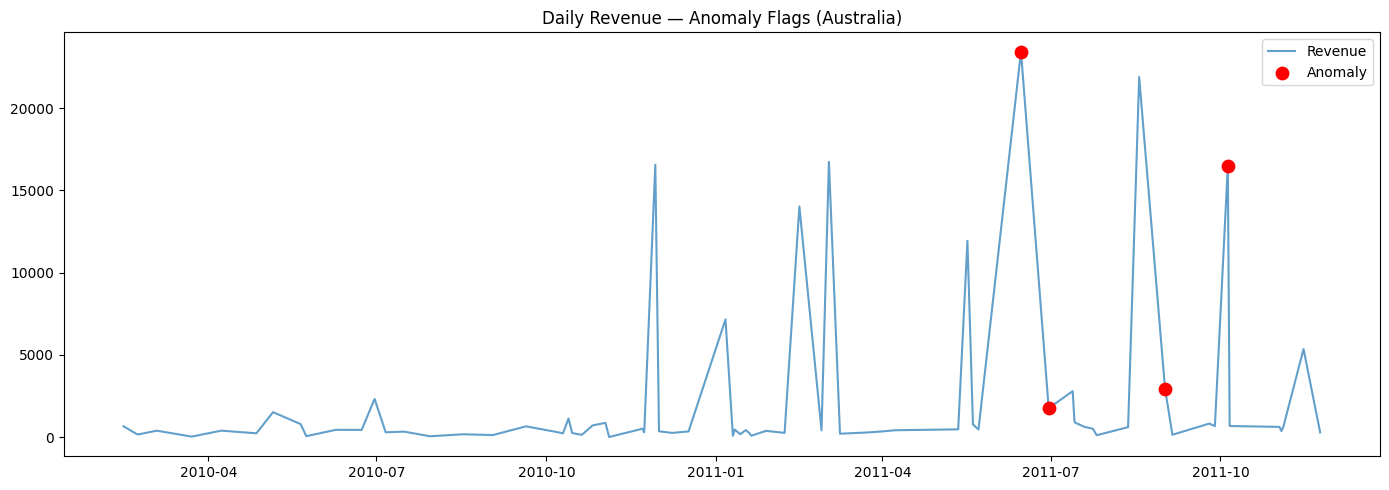

In [5]:
sample_country = result["country_name"].iloc[0]
sample = result[result["country_name"] == sample_country].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample["order_date"], sample["daily_revenue"], label="Revenue", alpha=0.7)

anom = sample[sample["is_anomaly"]]
ax.scatter(
    anom["order_date"],
    anom["daily_revenue"],
    color="red",
    s=80,
    label="Anomaly",
    zorder=5
)

ax.legend()
plt.title(f"Daily Revenue — Anomaly Flags ({sample_country})")
plt.tight_layout()
plt.show()

## Sample chart interpretation

The Australia example shows that the model is detecting unusual country-day behaviour relative to Australia's own historical pattern.

### What the chart shows
- the model correctly flags the largest spike in the series
- it also flags another major high-revenue day later in the timeline
- some lower-revenue days are also flagged because IsolationForest evaluates the full feature pattern, not just raw revenue magnitude
- not every visually large movement is necessarily flagged, because the model responds to multivariate context rather than only raw spike size

### Interpretation
This means the anomaly model should be understood as a detector of unusual combinations of:
- revenue level
- order volume
- weekday timing
- lagged revenue context
- rolling local trend

So the model is not a pure spike detector. It is a broader behavioural anomaly detector.

## Step 4 — Prepare final PostgreSQL load

Only rows with valid anomaly scores are written back to PostgreSQL.

Rows skipped due to low history are retained for notebook review but excluded from the warehouse anomaly table so that downstream BI tools receive only scored observations.

In [6]:
anomaly_final = result_scored[
    [
        "order_date",
        "country_name",
        "daily_revenue",
        "daily_orders",
        "anomaly_score",
        "is_anomaly",
        "anomaly_direction",
    ]
].copy()

print("Final anomaly rows:", len(anomaly_final))
print("Countries scored:", anomaly_final["country_name"].nunique())

display(anomaly_final.head())

Final anomaly rows: 2639
Countries scored: 18


,order_date,country_name,daily_revenue,daily_orders,anomaly_score,is_anomaly,anomaly_direction
0,2010-02-14,Australia,662.25,1,0.102260,False,normal
1,2010-02-21,Australia,202.56,1,0.107204,False,normal
2,2010-02-22,Australia,164.85,1,0.137288,False,normal
3,2010-03-04,Australia,394.59,1,0.192396,False,normal
4,2010-03-23,Australia,34.80,1,0.166892,False,normal


## PostgreSQL load summary

The final anomaly table prepared for PostgreSQL contains:
- **2,639 scored rows**
- **18 countries**
- **139 anomaly flags**

The warehouse output is now suitable for dashboarding and alerting workflows.

## Step 5 — Write scored anomalies back to PostgreSQL

We write only the successfully scored country-day observations back into PostgreSQL.

Rows skipped because of insufficient history are not loaded into the warehouse anomaly table. This keeps the downstream BI layer clean and ensures that Tableau or Power BI only consumes valid anomaly outputs with non-null scores.

In [7]:
with engine.begin() as conn:
    conn.execute(text("TRUNCATE TABLE ml_anomaly_scores"))

anomaly_final.to_sql(
    "ml_anomaly_scores",
    engine,
    if_exists="append",
    index=False,
    method="multi",
    chunksize=2000
)

print("Anomaly scores written to PostgreSQL successfully.")

Anomaly scores written to PostgreSQL successfully.


## PostgreSQL write status

The scored anomaly table was written successfully to PostgreSQL.

This warehouse-ready output is now available for anomaly dashboards, country-level monitoring, and future alerting workflows.

## Step 6 — Quick validation

We validate the PostgreSQL load by checking:
- total scored row count
- total anomaly count
- anomaly direction distribution
- anomaly distribution across countries

This confirms that the revised country-level modeling approach loaded correctly and produced a more balanced anomaly pattern than the earlier pooled-country version.

In [8]:
validation_sql = """
SELECT
    COUNT(*) AS row_count,
    SUM(CASE WHEN is_anomaly THEN 1 ELSE 0 END) AS anomaly_count
FROM ml_anomaly_scores
"""

direction_sql = """
SELECT
    anomaly_direction,
    COUNT(*) AS row_count
FROM ml_anomaly_scores
GROUP BY anomaly_direction
ORDER BY row_count DESC
"""

country_check_sql = """
SELECT
    country_name,
    COUNT(*) AS row_count,
    SUM(CASE WHEN is_anomaly THEN 1 ELSE 0 END) AS anomaly_count
FROM ml_anomaly_scores
GROUP BY country_name
ORDER BY anomaly_count DESC, row_count DESC
"""

display(pd.read_sql(validation_sql, engine))
display(pd.read_sql(direction_sql, engine))
display(pd.read_sql(country_check_sql, engine).head(15))

,row_count,anomaly_count
0,2639,139


,anomaly_direction,row_count
0,normal,2500
1,high,117
2,low,22


,country_name,row_count,anomaly_count
0,United Kingdom,602,31
1,Germany,383,20
2,France,332,17
3,EIRE,329,17
4,Netherlands,154,8
5,Spain,126,7
6,Belgium,123,7
7,Switzerland,80,4
8,Portugal,79,4
9,Australia,75,4


## Validation findings

The validation confirms that the country-level anomaly design is working as intended.

### Key results
- the warehouse contains **2,639 scored rows**
- the warehouse contains **139 anomaly flags**
- anomaly directions are split into:
  - **117 high**
  - **22 low**
  - **2,500 normal**
- anomalies are distributed across **18 countries**

### Country distribution
The United Kingdom still has the highest anomaly count, which is expected because it remains the largest market in the dataset.  
However, anomaly flags are no longer concentrated almost entirely in one geography.

The highest country-level anomaly counts include:
- United Kingdom: **31**
- Germany: **20**
- France: **17**
- EIRE: **17**
- Netherlands: **8**
- Spain: **7**
- Belgium: **7**

### Business interpretation
This revised approach is more credible for operational monitoring because each country is evaluated against its own historical behaviour. That makes anomaly detection more context-aware and reduces distortion caused by comparing low-volume markets directly against dominant ones.

## Modeling notes and limitations

This anomaly design is materially stronger than the earlier pooled-country version, but several modeling limitations should still be documented.

### Contamination assumption
The parameter `contamination=0.05` is a modeling assumption.

It means the IsolationForest model is allowed to flag roughly **5% of scored observations within each country** as anomalous.

This threshold is not learned automatically from business context.  
It is a practical starting point and may be refined later through sensitivity testing.

### Why the largest spike may not always be flagged
IsolationForest does **not** detect anomalies based only on the tallest revenue spike.

Instead, it evaluates **multivariate unusualness** using the full feature set:
- daily revenue
- daily orders
- day of week
- month
- previous day's revenue
- 7-period rolling revenue average

Because of that, a very large revenue spike may sometimes appear less isolated if the surrounding lag and rolling-context features make it look consistent with its local pattern.

Likewise, some lower-revenue days may still be flagged if their full feature combination is unusual relative to that country's historical behaviour.

### Country coverage limitation
Only countries with sufficient historical observations were scored.

Countries with low history were excluded from warehouse output to avoid statistically weak anomaly flags.

This improves reliability, but it also means the anomaly table is intentionally limited to countries with enough data to support local modeling.

### Portfolio interpretation
This notebook should be interpreted as a **country-aware anomaly monitoring layer**, not as a final alerting system.

The current approach is strong for dashboarding and exploratory monitoring, and it can later be extended through:
- contamination sensitivity testing
- alternative anomaly models
- alert thresholds by country
- anomaly root-cause narratives

## Final conclusion

This notebook successfully implemented country-level revenue anomaly detection using IsolationForest on top of the validated PostgreSQL warehouse.

### What was achieved
- built the anomaly base directly from warehouse data
- engineered temporal and lag-based country-level features
- applied anomaly detection separately within each country
- excluded low-history countries from forced scoring
- added anomaly direction labels for downstream BI use
- wrote the final scored anomaly outputs back into PostgreSQL
- validated that anomaly distribution is now more balanced across countries

### Key result
The final warehouse table contains:
- **2,639 scored rows**
- **139 anomaly flags**
- **18 countries**
- anomaly direction split of **117 high**, **22 low**, and **2,500 normal**

### Analytical note
This model detects multivariate unusual behaviour rather than only the largest raw revenue spikes.  
That makes it more flexible for operational monitoring, but it also means the model should be interpreted as a behavioural anomaly detector rather than a simple spike detector.

### Why this matters
The anomaly table is now ready for dashboard integration and gives the project a meaningful machine learning layer beyond descriptive analytics. It can later support alerting, forecasting comparisons, and AI-generated anomaly narratives.